# Bucket 2 Structural Decay Analysis
## YieldMax / YieldBOOST Put-Spread ETFs: Monte Carlo vs Closed-Form Theory

This notebook extends the MTYY deep-dive to all top **Bucket 2** candidates — income ETFs
that write weekly put spreads on **2× leveraged** single-stock ETFs.

For each candidate we:
1. Run a **10,000-path Monte Carlo** simulation (GBM + Student-t tails)
2. Compute the **closed-form theoretical decay** (lognormal put-spread expectation)
3. Validate MC vs Theory
4. Quantify the **short seller's net P&L** after distributions and borrow costs
5. Show how to construct the **pairs trade** (short income ETF + long β×underlying)

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import norm
import yfinance as yf
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")
pd.options.display.float_format = "{:,.4f}".format

REPO = Path(r"c:\Users\werdn\Documents\Investing\ls-algo")
print("Ready.")

Ready.


## 1. Universe Definition

Bucket 2 = ETFs with **0 < β ≤ 1.5** to their underlying. These are income ETFs
(YieldMax, YieldBOOST) that sell weekly put spreads on 2× leveraged trackers.

We select the **top 8 candidates** ranked by `decay_score` from the daily screener,
filtering for positive net decay and share availability.

In [2]:
UNIVERSE = [
    # Parameters sourced from etf_screened_today.csv
    # dist_rate_wk = actual observed weekly distribution as % of NAV (from dividendhistory.org)
    {"etf": "MTYY", "underlying": "MSTR", "lev_etf": "MSTU", "borrow": 0.084,
     "vol_und": 0.881, "beta_screener": 0.391, "decay_score": 0.551, "dist_rate_wk": 0.0191},
    {"etf": "MAAY", "underlying": "MARA", "lev_etf": "MRAL", "borrow": 0.098,
     "vol_und": 0.896, "beta_screener": 0.314, "decay_score": 0.313, "dist_rate_wk": 0.0188},
    {"etf": "COYY", "underlying": "COIN", "lev_etf": "CONL", "borrow": 0.260,
     "vol_und": 0.792, "beta_screener": 0.476, "decay_score": 0.194, "dist_rate_wk": 0.0190},
    {"etf": "IOYY", "underlying": "IONQ", "lev_etf": "IONL", "borrow": 0.077,
     "vol_und": 1.078, "beta_screener": 0.367, "decay_score": 0.192, "dist_rate_wk": 0.0187},
    {"etf": "XBTY", "underlying": "IBIT", "lev_etf": "BITX", "borrow": 0.046,
     "vol_und": 0.498, "beta_screener": 0.541, "decay_score": 0.170, "dist_rate_wk": 0.0184},
    {"etf": "TSYY", "underlying": "TSLA", "lev_etf": "TSLL", "borrow": 0.053,
     "vol_und": 0.626, "beta_screener": 0.541, "decay_score": 0.132, "dist_rate_wk": 0.0156},
    {"etf": "SMCY", "underlying": "SMCI", "lev_etf": "SMCL", "borrow": 0.063,
     "vol_und": 0.982, "beta_screener": 0.759, "decay_score": 0.108, "dist_rate_wk": 0.0155},
    {"etf": "HOYY", "underlying": "HOOD", "lev_etf": "HODU", "borrow": 0.213,
     "vol_und": 0.707, "beta_screener": 0.511, "decay_score": 0.101, "dist_rate_wk": 0.0187},
]

universe_df = pd.DataFrame(UNIVERSE)
universe_df.index = universe_df["etf"]
universe_df.index.name = None

print(f"Analyzing {len(UNIVERSE)} Bucket 2 candidates:")
print()
print(universe_df[["underlying", "lev_etf", "vol_und", "borrow", "beta_screener", "decay_score", "dist_rate_wk"]]
      .to_string(float_format="{:.3f}".format))

Analyzing 8 Bucket 2 candidates:

     underlying lev_etf  vol_und  borrow  beta_screener  decay_score
MTYY       MSTR    MSTU    0.881   0.084          0.391        0.551
MAAY       MARA    MRAL    0.896   0.098          0.314        0.313
COYY       COIN    CONL    0.792   0.260          0.476        0.194
IOYY       IONQ    IONL    1.078   0.077          0.367        0.192
XBTY       IBIT    BITX    0.498   0.046          0.541        0.170
TSYY       TSLA    TSLL    0.626   0.053          0.541        0.132
SMCY       SMCI    SMCL    0.982   0.063          0.759        0.108
HOYY       HOOD    HODU    0.707   0.213          0.511        0.101


## 2. Empirical Price Data & Realised Metrics

Download adjusted prices for each triplet (income ETF, underlying, 2× leveraged ETF)
and compute realised volatility, beta, and total-return decay.

**Note:** yfinance downloads may fail due to rate-limiting. The MC and theoretical
analysis in subsequent sections uses screener parameters and does not depend on live data.
Re-run this cell manually if downloads fail.

In [ ]:
import time

START = "2024-06-01"

all_tickers = sorted(set(
    t for u in UNIVERSE for t in [u["etf"], u["underlying"], u["lev_etf"]]
))

BATCH = 4
prices_frames = []
failed = []
for b in range(0, len(all_tickers), BATCH):
    batch = all_tickers[b:b + BATCH]
    print(f"  Batch {b//BATCH + 1}: {batch}")
    try:
        raw = yf.download(batch, start=START, auto_adjust=True, progress=False)
        if raw.empty:
            failed.extend(batch)
            continue
        if len(batch) > 1:
            close = raw["Close"]
        else:
            close = raw[["Close"]].rename(columns={"Close": batch[0]})
        prices_frames.append(close)
    except Exception as exc:
        print(f"    Failed: {exc}")
        failed.extend(batch)
    time.sleep(2)

if prices_frames:
    prices = pd.concat(prices_frames, axis=1).dropna(how="all")
else:
    prices = pd.DataFrame()

if failed:
    print(f"\nFailed tickers: {failed}")

rets = prices.pct_change().dropna(how="all") if not prices.empty else pd.DataFrame()
print(f"\nPrice matrix: {prices.shape[0]} days × {prices.shape[1]} tickers")
if not prices.empty:
    print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")

empirical_rows = []
for u in UNIVERSE:
    etf, und, lev = u["etf"], u["underlying"], u["lev_etf"]
    
    vol_und_realised = vol_lev_realised = beta_static = tr_etf_ann = np.nan
    n_days = 0
    
    if und in rets.columns:
        vol_und_realised = rets[und].dropna().std() * np.sqrt(252)
    if lev in rets.columns:
        vol_lev_realised = rets[lev].dropna().std() * np.sqrt(252)
    
    if etf in rets.columns and und in rets.columns:
        pair = rets[[etf, und]].dropna()
        n_days = len(pair)
        if n_days > 30:
            beta_static = np.polyfit(pair[und], pair[etf], 1)[0]
    
    if etf in prices.columns:
        etf_p = prices[etf].dropna()
        if len(etf_p) > 20:
            tr = etf_p.iloc[-1] / etf_p.iloc[0] - 1
            cal_days = (etf_p.index[-1] - etf_p.index[0]).days
            tr_etf_ann = (1 + tr) ** (365.25 / max(cal_days, 1)) - 1
    
    empirical_rows.append({
        "ETF": etf, "Underlying": und, "Lev_ETF": lev,
        "Vol_Und_Realised": vol_und_realised, "Vol_Lev_Realised": vol_lev_realised,
        "Beta_to_Und": beta_static, "ETF_Ann_TR": tr_etf_ann, "Days_Data": n_days,
    })

empirical_df = pd.DataFrame(empirical_rows).set_index("ETF")
print()
print("Empirical statistics:")
print(empirical_df.to_string(float_format="{:.3f}".format))

  Batch 1: ['BITX', 'COIN', 'CONL', 'COYY']


Failed to get ticker 'COIN' reason: Expecting value: line 1 column 1 (char 0)


Failed to get ticker 'BITX' reason: Expecting value: line 1 column 1 (char 0)


Failed to get ticker 'CONL' reason: Expecting value: line 1 column 1 (char 0)


Failed to get ticker 'COYY' reason: Expecting value: line 1 column 1 (char 0)


...

Failed to get ticker 'TSLL' reason: Expecting value: line 1 column 1 (char 0)



4 Failed downloads:


['TSYY', 'XBTY', 'TSLL']: YFTzMissingError('$%ticker%: possibly delisted; No timezone found')


['TSLA']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')



Failed tickers: ['BITX', 'COIN', 'CONL', 'COYY', 'HODU', 'HOOD', 'HOYY', 'IBIT', 'IONL', 'IONQ', 'IOYY', 'MAAY', 'MARA', 'MRAL', 'MSTR', 'MSTU', 'MTYY', 'SMCI', 'SMCL', 'SMCY', 'TSLA', 'TSLL', 'TSYY', 'XBTY']

Price matrix: 0 days × 0 tickers

Empirical statistics:
     Underlying Lev_ETF  Vol_Und_Realised  Vol_Lev_Realised  Beta_to_Und  ETF_Ann_TR  Days_Data
ETF                                                                                            
MTYY       MSTR    MSTU               NaN               NaN          NaN         NaN          0
MAAY       MARA    MRAL               NaN               NaN          NaN         NaN          0
COYY       COIN    CONL               NaN               NaN          NaN         NaN          0
IOYY       IONQ    IONL               NaN               NaN          NaN         NaN          0
XBTY       IBIT    BITX               NaN               NaN          NaN         NaN          0
TSYY       TSLA    TSLL               NaN               NaN  

## 3. Generalised Monte Carlo Engine

The same framework as the MTYY deep-dive, now parameterised for any underlying volatility.

**Model**: Underlying follows GBM → 2× daily leveraged ETF via exact compounding →
52 weekly put-spread cycles where notional is resized to current NAV each week.

**Critical fix**: Distributions are tracked using **actual observed dividend rates** from
dividendhistory.org, not the theoretical Black-Scholes premium. Actual distributions
average ~65% of the BS premium. This is essential for computing the correct short seller P&L:

**Net Short P&L = NAV Decay − Distributions Paid − Borrow Cost**

In [4]:
# ── Simulation constants ─────────────────────────────────────────────────────
N_SIMS   = 10_000
WEEKS    = 52
DPW      = 5
TDAYS_YR = 252
SIM_DAYS = WEEKS * DPW
LEVERAGE = 2

SHORT_K  = 0.95
LONG_K   = 0.88
IV_MULT  = 1.10
ER       = 0.0099
T_DF     = 5


def bs_put_unit(K_frac, sigma, tau, r=0.0):
    """Black-Scholes put price at unit spot, strike = K_frac."""
    sq = np.sqrt(tau)
    d1 = (-np.log(K_frac) + (r + 0.5 * sigma**2) * tau) / (sigma * sq)
    d2 = d1 - sigma * sq
    return K_frac * np.exp(-r * tau) * norm.cdf(-d2) - norm.cdf(-d1)


def simulate_nav(und_sigma, dist_rate_wk, und_mu=0.0, n_sims=N_SIMS, t_df=T_DF, seed=42):
    """
    Simulate n_sims one-year paths for a put-spread income ETF.

    NAV evolves as: NAV_{w+1} = NAV_w - spread_loss - fees
    (premium earned ≈ distribution paid, so they cancel in the NAV update)

    Distributions are tracked using the ACTUAL observed dividend rate,
    not the theoretical BS premium. This is critical for computing the
    short seller's true P&L.
    """
    rng = np.random.default_rng(seed)
    lev_sigma = LEVERAGE * und_sigma
    sigma_imp = IV_MULT * lev_sigma
    fee_wk    = ER / WEEKS
    tau       = DPW / TDAYS_YR

    prem_frac = float(bs_put_unit(SHORT_K, sigma_imp, tau)
                      - bs_put_unit(LONG_K, sigma_imp, tau))

    d_sigma = und_sigma / np.sqrt(TDAYS_YR)
    d_mu    = und_mu / TDAYS_YR

    if t_df and t_df > 2:
        z = rng.standard_t(t_df, size=(n_sims, SIM_DAYS))
        z /= np.sqrt(t_df / (t_df - 2))
    else:
        z = rng.standard_normal(size=(n_sims, SIM_DAYS))

    daily_ret = d_mu + d_sigma * z
    lev_daily = LEVERAGE * daily_ret
    lev_price = np.ones((n_sims, SIM_DAYS + 1))
    lev_price[:, 1:] = np.cumprod(1 + lev_daily, axis=1)

    nav = np.ones(n_sims)
    nav_paths = np.zeros((n_sims, WEEKS + 1))
    nav_paths[:, 0] = 1.0
    distributions = np.zeros(n_sims)
    spread_losses = np.zeros(n_sims)
    fees_total    = np.zeros(n_sims)
    itm_count     = np.zeros(n_sims)

    for wk in range(WEEKS):
        d0 = wk * DPW
        d1 = d0 + DPW
        r_week = lev_price[:, d1] / lev_price[:, d0]

        loss_frac = (np.maximum(SHORT_K - r_week, 0.0)
                     - np.maximum(LONG_K - r_week, 0.0))
        itm_count += (r_week < SHORT_K).astype(float)

        loss_dollar = loss_frac * nav
        dist_dollar = dist_rate_wk * nav
        fee_dollar  = fee_wk * nav

        nav = nav - loss_dollar - fee_dollar
        nav = np.maximum(nav, 0.0)

        distributions += dist_dollar
        spread_losses += loss_dollar
        fees_total    += fee_dollar
        nav_paths[:, wk + 1] = nav

    return {
        "nav_finals":    nav,
        "distributions": distributions,
        "spread_losses": spread_losses,
        "fees":          fees_total,
        "nav_paths":     nav_paths,
        "itm_count":     itm_count,
        "prem_frac":     prem_frac,
        "dist_rate_wk":  dist_rate_wk,
        "lev_sigma":     lev_sigma,
        "sigma_imp":     sigma_imp,
    }


# ── Closed-form theoretical decay ─────────────────────────────────────────────
def expected_spread_loss(und_sigma, und_mu=0.0, K_h=SHORT_K, K_l=LONG_K, tau=DPW/TDAYS_YR):
    """E[L] under physical measure for lognormal 2x leveraged weekly returns."""
    sigma = und_sigma
    m = (2 * und_mu - 2 * sigma**2) * tau
    v = 2 * sigma * np.sqrt(tau)
    F = np.exp(2 * und_mu * tau)

    def _put(K):
        a = (np.log(K) - m) / v
        b = a - v
        return K * norm.cdf(a) - F * norm.cdf(b)

    return _put(K_h) - _put(K_l)


def theoretical_decay(und_sigma, und_mu=0.0, f=ER/WEEKS):
    """Closed-form annual NAV decay."""
    EL = expected_spread_loss(und_sigma, und_mu)
    return 1 - (1 - EL - f) ** WEEKS


def theoretical_itm_prob(und_sigma, und_mu=0.0, K_h=SHORT_K, tau=DPW/TDAYS_YR):
    m = (2 * und_mu - 2 * und_sigma**2) * tau
    v = 2 * und_sigma * np.sqrt(tau)
    return norm.cdf((np.log(K_h) - m) / v)


def theoretical_short_pnl(und_sigma, dist_rate_wk, borrow, und_mu=0.0, f=ER/WEEKS):
    """Closed-form short seller P&L = NAV_decay - distributions_paid - borrow."""
    EL = expected_spread_loss(und_sigma, und_mu)
    q = 1 - EL - f
    nav_decay = 1 - q**WEEKS
    nav_series_sum = (1 - q**WEEKS) / (1 - q)
    total_dist = dist_rate_wk * nav_series_sum
    return nav_decay - total_dist - borrow


print("MC engine and closed-form functions defined.")
print(f"Simulation: {N_SIMS:,} paths × {WEEKS} weeks × {DPW} days")
print(f"Strikes: short {SHORT_K:.0%} / long {LONG_K:.0%}  |  IV mult: {IV_MULT}×  |  ER: {ER:.2%}")
print("Distribution rates calibrated from actual dividends (dividendhistory.org)")

MC engine and closed-form functions defined.
Simulation: 10,000 paths × 52 weeks × 5 days
Strikes: short 95% / long 88%  |  IV mult: 1.1×  |  ER: 0.99%


## 4. Run Simulations for All Candidates

For each candidate, run 10,000 Monte Carlo paths and compute the theoretical prediction.
Store all results for cross-comparison.

In [5]:
results_all = {}

for u in UNIVERSE:
    etf = u["etf"]
    sigma = u["vol_und"]
    borrow = u["borrow"]
    drw = u["dist_rate_wk"]
    
    res = simulate_nav(und_sigma=sigma, dist_rate_wk=drw, seed=42)
    
    nav_finals = res["nav_finals"]
    decay_mc = np.mean(1 - nav_finals) * 100
    decay_median = np.median(1 - nav_finals) * 100
    dist_pct = np.mean(res["distributions"]) * 100
    
    decay_th = theoretical_decay(sigma) * 100
    EL = expected_spread_loss(sigma)
    itm_th = theoretical_itm_prob(sigma) * 100
    itm_mc = np.mean(res["itm_count"]) / WEEKS * 100
    
    # Short seller P&L = NAV_decay - distributions_paid - borrow
    short_pnl_mc = decay_mc - dist_pct - borrow * 100
    short_pnl_th = theoretical_short_pnl(sigma, drw, borrow) * 100
    
    results_all[etf] = {
        **u,
        "mc_result": res,
        "decay_mc_mean": decay_mc,
        "decay_mc_median": decay_median,
        "decay_mc_5": np.percentile(1 - nav_finals, 5) * 100,
        "decay_mc_95": np.percentile(1 - nav_finals, 95) * 100,
        "decay_theory": decay_th,
        "EL_weekly": EL * 100,
        "itm_mc": itm_mc,
        "itm_theory": itm_th,
        "prem_frac": res["prem_frac"] * 100,
        "prem_ann": res["prem_frac"] * WEEKS * 100,
        "dist_pct": dist_pct,
        "dist_rate_ann": drw * WEEKS * 100,
        "short_pnl_mc": short_pnl_mc,
        "short_pnl_th": short_pnl_th,
        "wipeout_pct": np.mean(nav_finals < 0.01) * 100,
        "mean_spread_loss": np.mean(res["spread_losses"]) * 100,
        "mean_fees": np.mean(res["fees"]) * 100,
        "mean_dist": dist_pct,
    }

print("All simulations complete.")
print()

summary_rows = []
for etf, r in results_all.items():
    summary_rows.append({
        "ETF": etf,
        "Underlying": r["underlying"],
        "σ_und": r["vol_und"],
        "NAV Decay%": r["decay_mc_mean"],
        "Dist Paid%": r["dist_pct"],
        "Borrow%": r["borrow"] * 100,
        "Short P&L%": r["short_pnl_mc"],
        "Theory P&L%": r["short_pnl_th"],
        "ITM%": r["itm_mc"],
    })

summary_df = pd.DataFrame(summary_rows).set_index("ETF")
print("=" * 100)
print("BUCKET 2 DECAY ANALYSIS — SHORT SELLER P&L (with actual distributions)")
print("=" * 100)
print(summary_df.to_string(float_format="{:.1f}".format))
print()
print("Short P&L = NAV Decay - Distributions Paid - Borrow Cost")
positive = sum(1 for r in results_all.values() if r["short_pnl_mc"] > 0)
print(f"{positive}/{len(results_all)} candidates have positive net short P&L")

All simulations complete.

BUCKET 2 DECAY ANALYSIS — SUMMARY
     Underlying  σ_und  σ_2x  MC Decay%  Theory%  Δ (pp)  Borrow%  Net Edge%  ITM% MC  Wipeout%
ETF                                                                                            
MTYY       MSTR    0.9   1.8       76.2     78.0     1.9      8.4       67.8     44.7       0.0
MAAY       MARA    0.9   1.8       76.4     78.3     1.9      9.8       66.6     44.9       0.0
COYY       COIN    0.8   1.6       74.4     76.3     1.9     26.0       48.4     43.4       0.0
IOYY       IONQ    1.1   2.2       79.0     80.8     1.8      7.7       71.3     47.0       0.0
XBTY       IBIT    0.5   1.0       63.5     65.7     2.2      4.6       58.9     36.7       0.0
TSYY       TSLA    0.6   1.3       69.6     71.7     2.1      5.3       64.3     40.2       0.0
SMCY       SMCI    1.0   2.0       77.8     79.6     1.8      6.3       71.5     45.9       0.0
HOYY       HOOD    0.7   1.4       72.2     74.2     2.0     21.3       50.

## 5. Detailed Results: Individual ETF Cards

For each candidate, show the Monte Carlo distribution of annual decay,
NAV path fan chart, and key statistics.

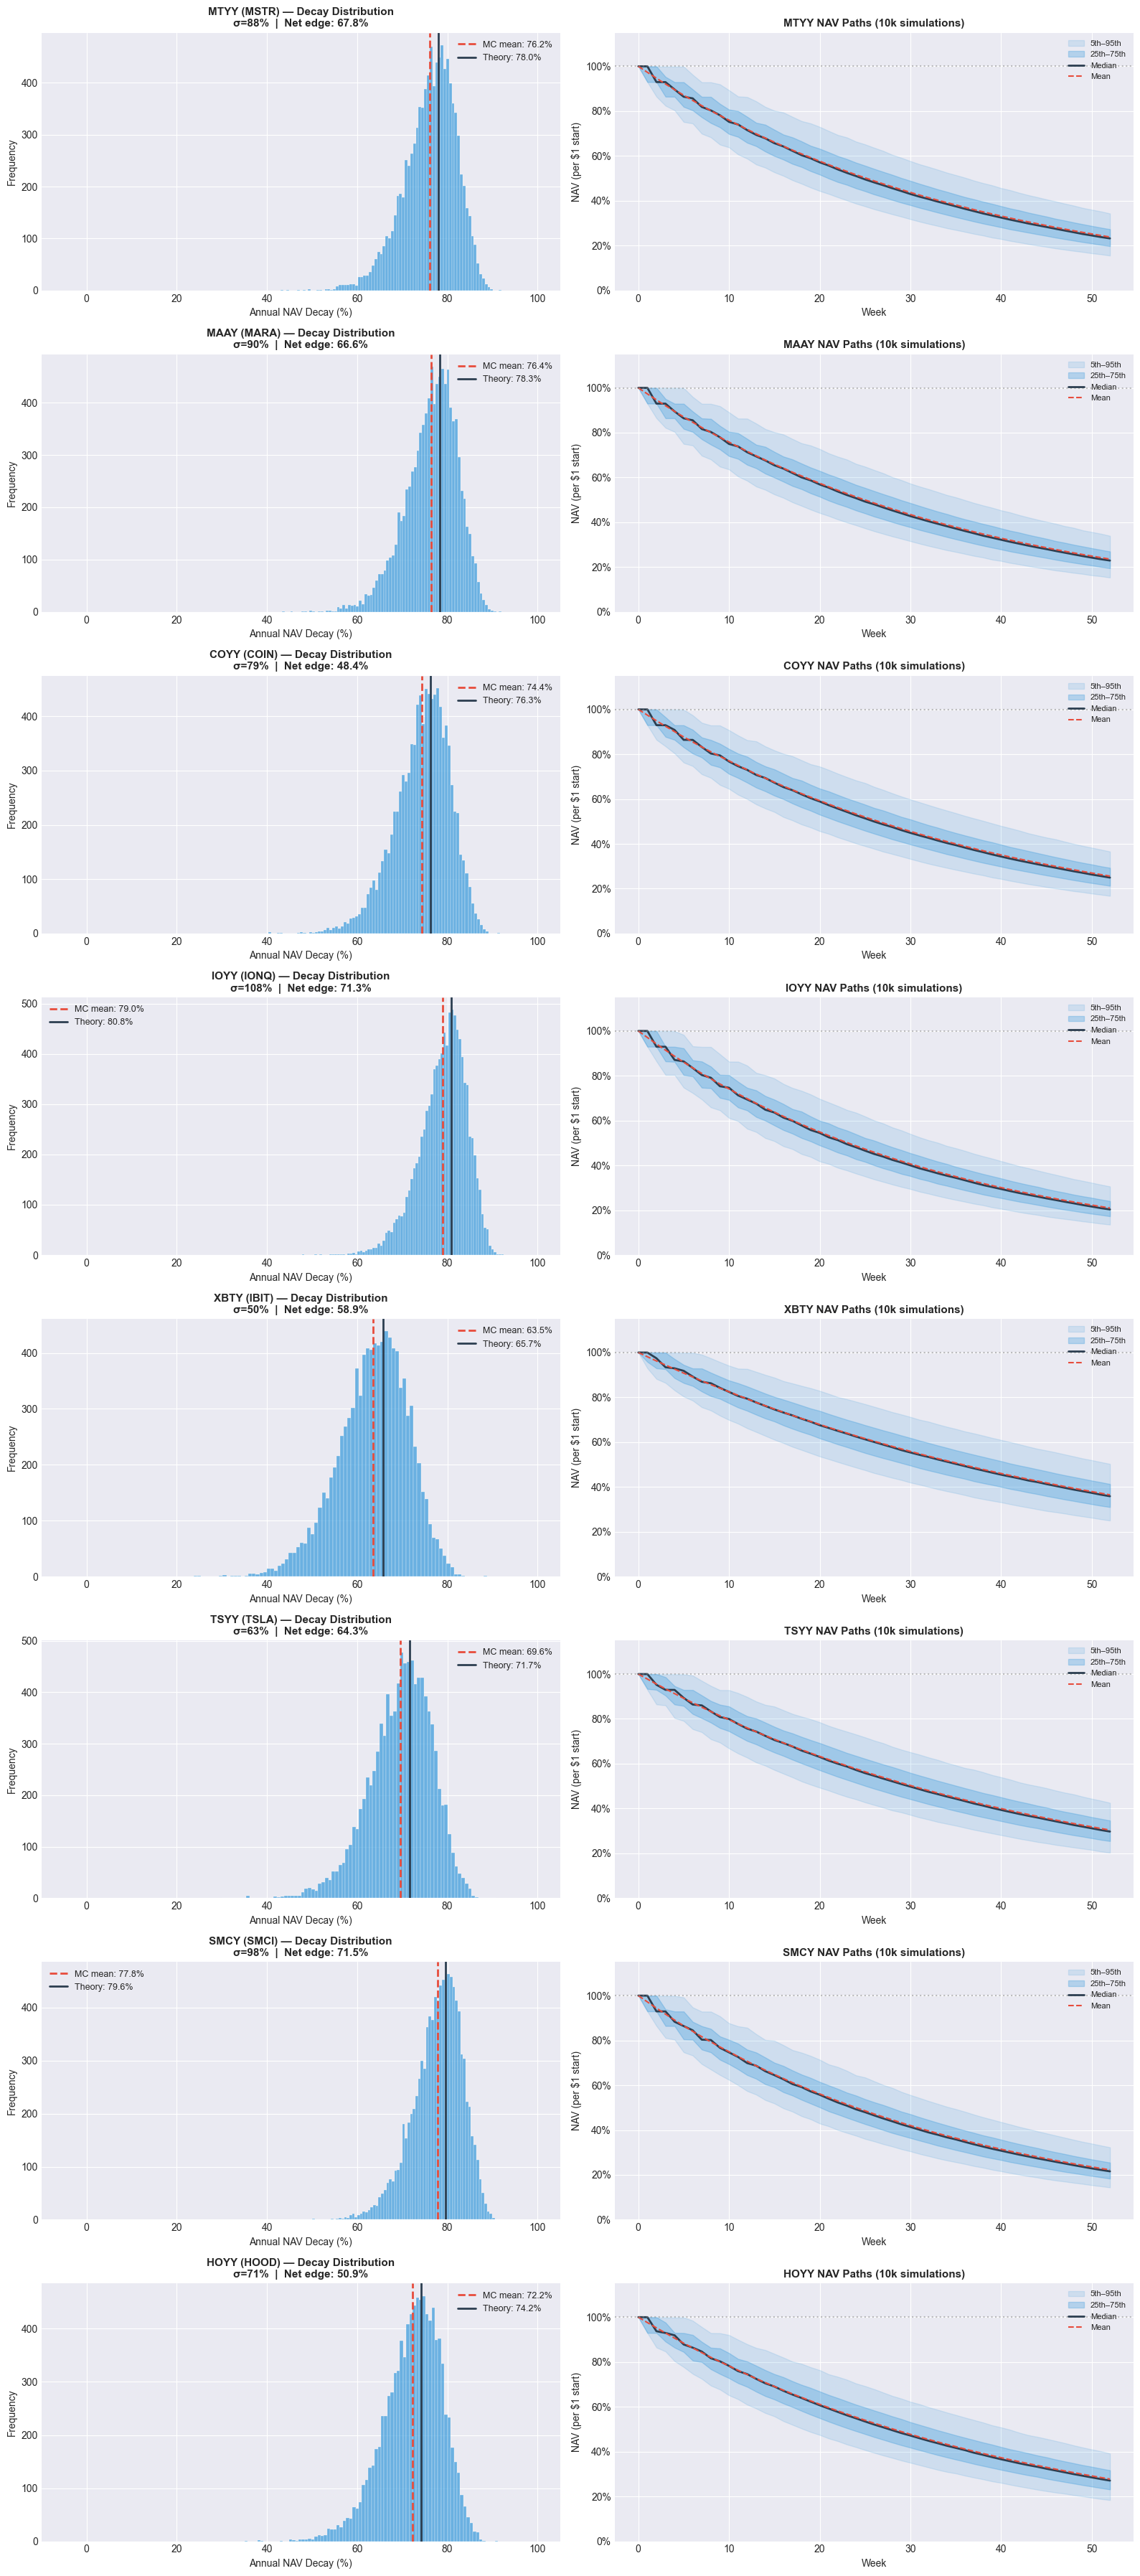

Saved: bucket2_individual_cards.png


In [6]:
n_etfs = len(UNIVERSE)
fig, axes = plt.subplots(n_etfs, 2, figsize=(16, 4.5 * n_etfs))

for i, u in enumerate(UNIVERSE):
    etf = u["etf"]
    r = results_all[etf]
    mc = r["mc_result"]
    nav_finals = mc["nav_finals"]
    nav_paths = mc["nav_paths"]
    
    # Left: Decay distribution
    ax1 = axes[i, 0]
    decay_pct = (1 - nav_finals) * 100
    ax1.hist(decay_pct, bins=80, color="#3498db", alpha=0.7, edgecolor="white", linewidth=0.3)
    ax1.axvline(r["decay_mc_mean"], color="#e74c3c", linewidth=2, linestyle="--",
               label=f"MC mean: {r['decay_mc_mean']:.1f}%")
    ax1.axvline(r["decay_theory"], color="#2c3e50", linewidth=2, linestyle="-",
               label=f"Theory: {r['decay_theory']:.1f}%")
    ax1.set_xlabel("Annual NAV Decay (%)")
    ax1.set_ylabel("Frequency")
    ax1.set_title(f"{etf} ({u['underlying']}) — Decay Distribution\n"
                  f"σ={u['vol_und']:.0%}  |  Short P&L: {r['short_pnl_mc']:+.1f}%",
                  fontsize=11, fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.set_xlim(-10, 105)
    
    # Right: NAV path fan chart
    ax2 = axes[i, 1]
    weeks_x = np.arange(WEEKS + 1)
    p5  = np.percentile(nav_paths, 5, axis=0)
    p25 = np.percentile(nav_paths, 25, axis=0)
    p50 = np.median(nav_paths, axis=0)
    p75 = np.percentile(nav_paths, 75, axis=0)
    p95 = np.percentile(nav_paths, 95, axis=0)
    
    ax2.fill_between(weeks_x, p5, p95, alpha=0.15, color="#3498db", label="5th–95th")
    ax2.fill_between(weeks_x, p25, p75, alpha=0.3, color="#3498db", label="25th–75th")
    ax2.plot(weeks_x, p50, color="#2c3e50", linewidth=2, label="Median")
    ax2.plot(weeks_x, np.mean(nav_paths, axis=0), color="#e74c3c", linewidth=1.5,
            linestyle="--", label="Mean")
    ax2.axhline(1.0, color="gray", linestyle=":", alpha=0.5)
    ax2.set_xlabel("Week")
    ax2.set_ylabel("NAV (per $1 start)")
    ax2.set_title(f"{etf} NAV Paths (10k simulations)", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=8, loc="upper right")
    ax2.set_ylim(0, 1.15)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig(REPO / "notebooks" / "bucket2_individual_cards.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bucket2_individual_cards.png")

## 6. Cross-Comparison: MC vs Theory & Short Seller P&L Ranking

Compare all candidates side-by-side. **Short P&L = NAV Decay - Distributions Paid - Borrow Cost.**
Distribution rates are calibrated from actual dividends (dividendhistory.org).
The closed-form formula should closely match
MC for each, differing only due to fat tails (Student-t vs lognormal).

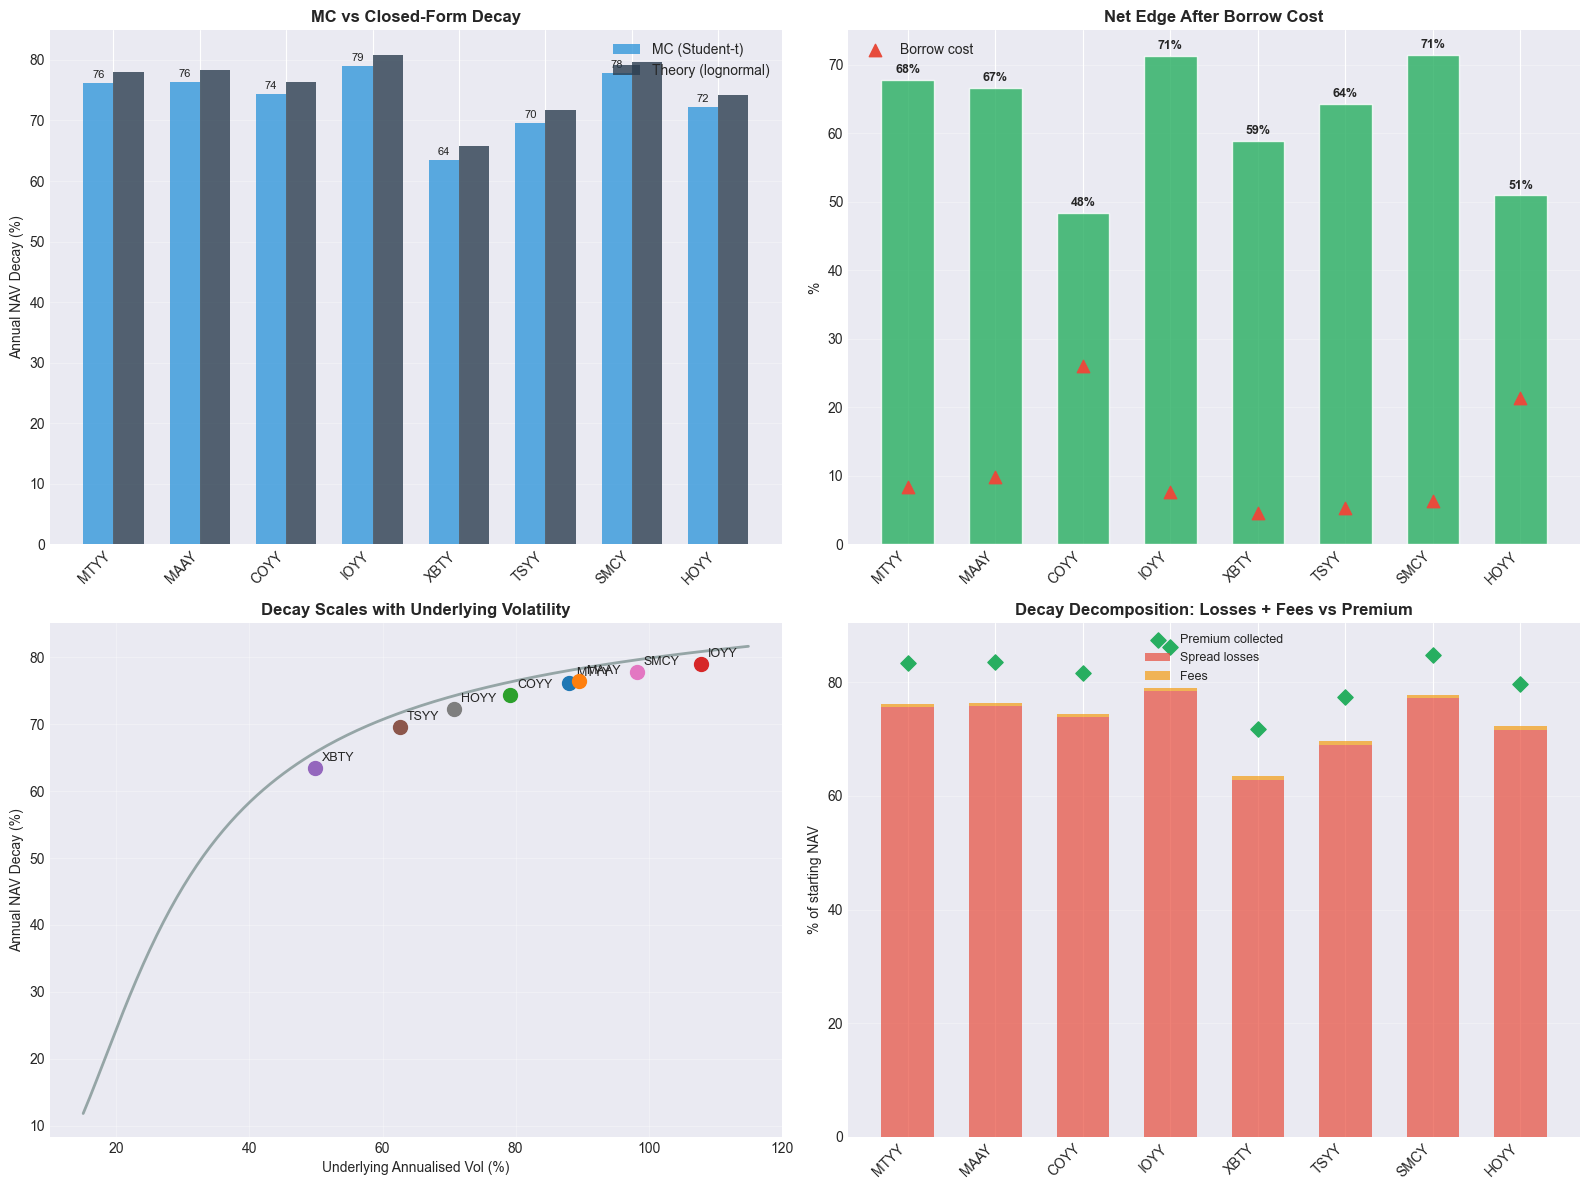

Saved: bucket2_cross_comparison.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

etf_names = [u["etf"] for u in UNIVERSE]
x_pos = np.arange(len(etf_names))
bar_w = 0.35

mc_decays   = [results_all[e]["decay_mc_mean"] for e in etf_names]
th_decays   = [results_all[e]["decay_theory"] for e in etf_names]
borrows     = [results_all[e]["borrow"] * 100 for e in etf_names]
dist_costs  = [results_all[e]["dist_pct"] for e in etf_names]
short_pnls  = [results_all[e]["short_pnl_mc"] for e in etf_names]
vols        = [results_all[e]["vol_und"] * 100 for e in etf_names]

# Panel 1: MC vs Theory decay
ax = axes[0, 0]
bars1 = ax.bar(x_pos - bar_w/2, mc_decays, bar_w, label="MC (Student-t)", color="#3498db", alpha=0.8)
bars2 = ax.bar(x_pos + bar_w/2, th_decays, bar_w, label="Theory (lognormal)", color="#2c3e50", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(etf_names, rotation=45, ha="right")
ax.set_ylabel("Annual NAV Decay (%)")
ax.set_title("MC vs Closed-Form Decay", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=8)

# Panel 2: Short seller P&L (decay - distributions - borrow)
ax = axes[0, 1]
colors = ["#27ae60" if e > 0 else "#e74c3c" for e in short_pnls]
ax.bar(x_pos, short_pnls, 0.6, color=colors, alpha=0.8, edgecolor="white")
ax.scatter(x_pos, borrows, color="#e74c3c", marker="^", s=60, zorder=5, label="Borrow cost")
ax.scatter(x_pos, dist_costs, color="#f39c12", marker="v", s=60, zorder=5, label="Distributions paid")
ax.set_xticks(x_pos)
ax.set_xticklabels(etf_names, rotation=45, ha="right")
ax.set_ylabel("%")
ax.set_title("Net Short P&L (Decay - Dist - Borrow)", fontweight="bold")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
for j, (e, v) in enumerate(zip(short_pnls, etf_names)):
    ax.text(j, e + (1 if e > 0 else -2.5), f"{e:+.0f}%", ha="center", fontsize=9, fontweight="bold")

# Panel 3: Decay vs Underlying Vol (continuous curve + data points)
ax = axes[1, 0]
vol_curve = np.linspace(0.15, 1.15, 200)
decay_curve = [theoretical_decay(s) * 100 for s in vol_curve]
ax.plot(vol_curve * 100, decay_curve, color="#95a5a6", linewidth=2, label="Theoretical curve")
for etf_n, v, d in zip(etf_names, vols, mc_decays):
    ax.scatter(v, d, s=100, zorder=5)
    ax.annotate(etf_n, (v, d), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel("Underlying Annualised Vol (%)")
ax.set_ylabel("Annual NAV Decay (%)")
ax.set_title("Decay Scales with Underlying Volatility", fontweight="bold")
ax.grid(True, alpha=0.3)

# Panel 4: Short seller P&L decomposition
ax = axes[1, 1]
decay_bars = [results_all[e]["decay_mc_mean"] for e in etf_names]
dists_bars = [results_all[e]["dist_pct"] for e in etf_names]
borrow_bars = [results_all[e]["borrow"] * 100 for e in etf_names]
net_bars = [results_all[e]["short_pnl_mc"] for e in etf_names]
ax.bar(x_pos, decay_bars, 0.6, label="NAV Decay (profit)", color="#27ae60", alpha=0.7)
ax.bar(x_pos, [-d for d in dists_bars], 0.6, label="Distributions (cost)", color="#e74c3c", alpha=0.7)
ax.bar(x_pos, [-b for b in borrow_bars], 0.6, bottom=[-d for d in dists_bars], label="Borrow (cost)", color="#f39c12", alpha=0.7)
ax.scatter(x_pos, net_bars, color="#2c3e50", marker="D", s=80, zorder=5, label="Net short P&L", linewidths=1.5, edgecolors="white")
ax.set_xticks(x_pos)
ax.set_xticklabels(etf_names, rotation=45, ha="right")
ax.set_ylabel("% of starting NAV")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Short Seller P&L Decomposition", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(REPO / "notebooks" / "bucket2_cross_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bucket2_cross_comparison.png")

## 7. Volatility Regime Sensitivity

How does each ETF's decay change if its underlying's volatility shifts?
Sweep vol ±50% around current levels.

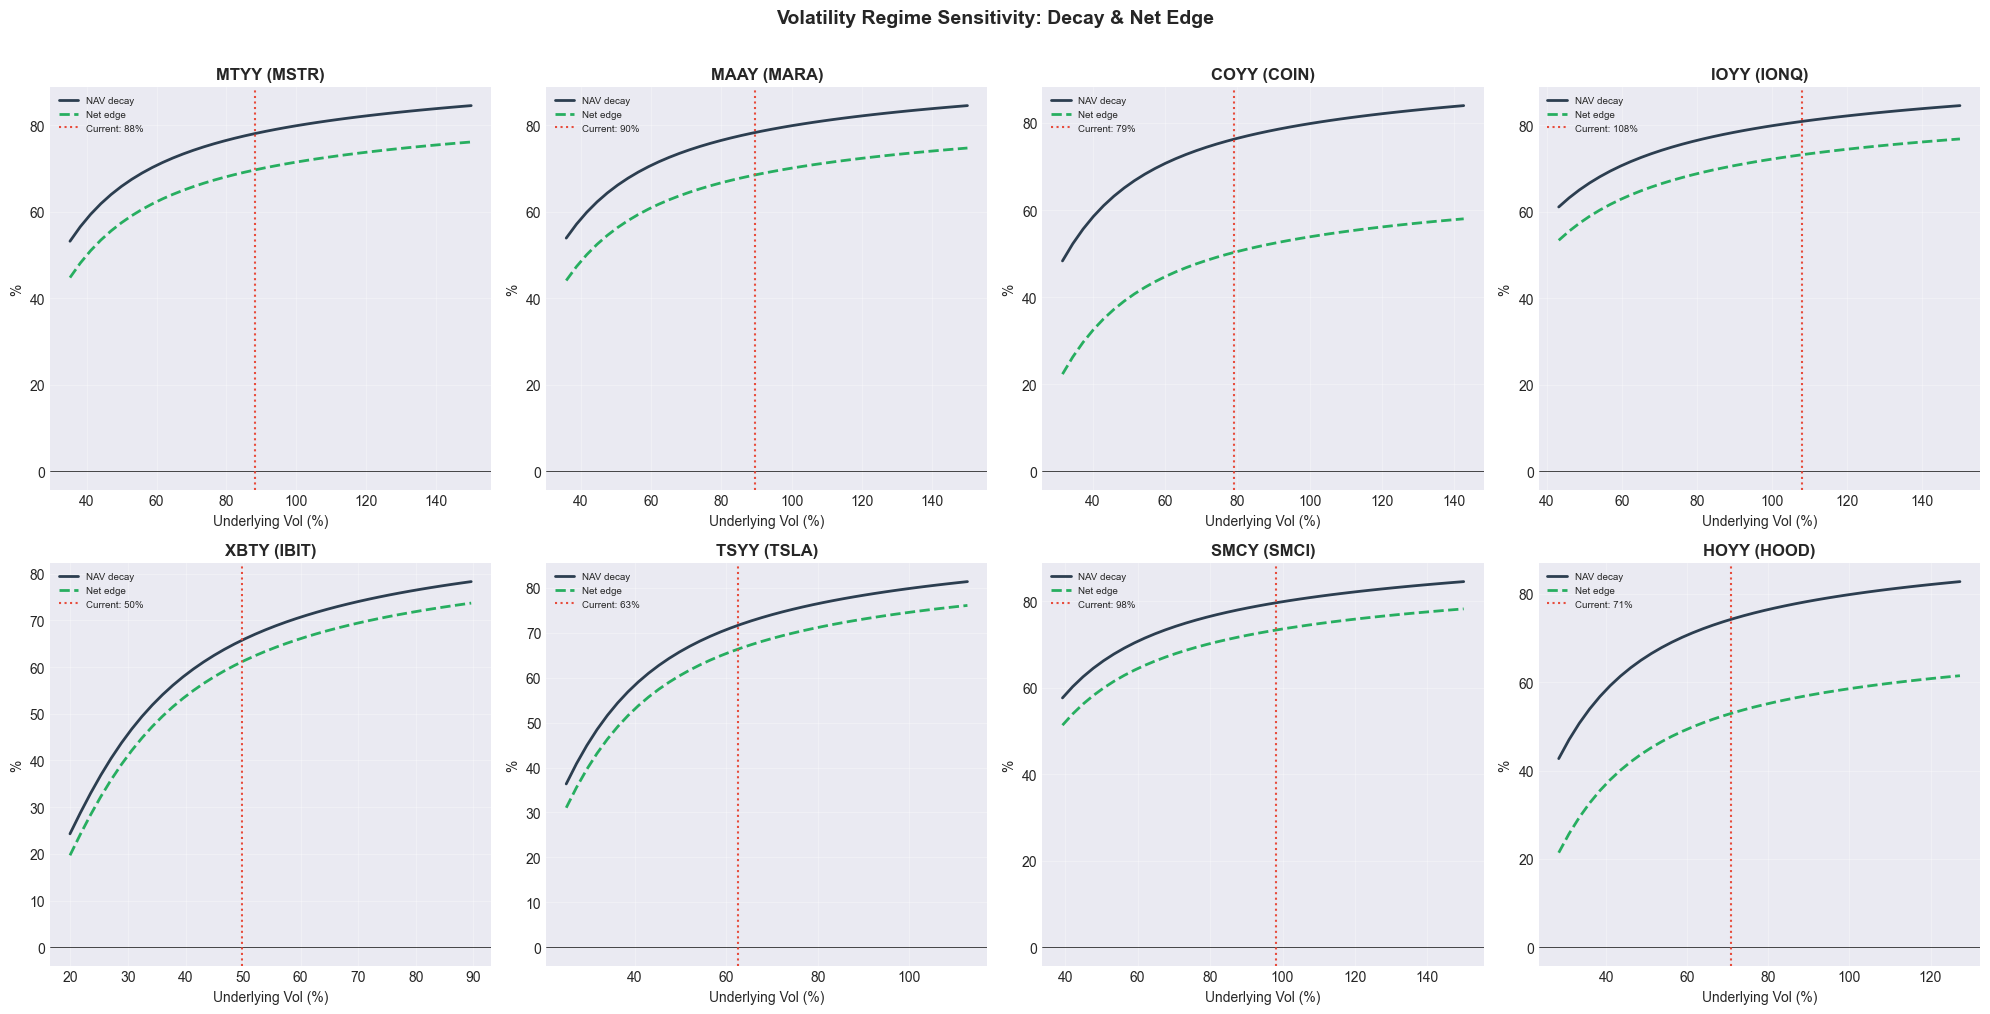

Saved: bucket2_vol_sensitivity.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, u in enumerate(UNIVERSE):
    etf = u["etf"]
    base_vol = u["vol_und"]
    borrow = u["borrow"]
    
    drw = u["dist_rate_wk"]
    vol_grid = np.linspace(max(0.10, base_vol * 0.4), min(1.5, base_vol * 1.8), 40)
    th_decay = np.array([theoretical_decay(s) * 100 for s in vol_grid])
    net_pnl = np.array([theoretical_short_pnl(s, drw, borrow) * 100 for s in vol_grid])
    
    ax = axes[i]
    ax.plot(vol_grid * 100, th_decay, color="#2c3e50", linewidth=2, label="NAV decay")
    ax.plot(vol_grid * 100, net_pnl, color="#27ae60", linewidth=2, linestyle="--", label="Net short P&L")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(base_vol * 100, color="#e74c3c", linestyle=":", linewidth=1.5,
              label=f"Current: {base_vol:.0%}")
    
    # Breakeven vol (where net edge = 0)
    be_idx = np.argmin(np.abs(net_pnl))
    if net_pnl[0] < 0 and net_pnl[-1] > 0:
        be_vol = vol_grid[be_idx] * 100
        ax.axvline(be_vol, color="orange", linestyle="--", alpha=0.7)
        ax.text(be_vol + 1, ax.get_ylim()[1] * 0.1, f"BE: {be_vol:.0f}%",
               fontsize=8, color="orange")
    
    ax.set_xlabel("Underlying Vol (%)")
    ax.set_ylabel("%")
    ax.set_title(f"{etf} ({u['underlying']})", fontweight="bold")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.suptitle("Volatility Regime Sensitivity: Decay & Net Short P&L (incl. distributions)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPO / "notebooks" / "bucket2_vol_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bucket2_vol_sensitivity.png")

## 8. Beta-Hedged Pairs Trade Construction

The strategy: **short income ETF** + **long β × underlying** = market-neutral alpha capture.

For each candidate, we compute:
- Hedge ratio from empirical beta
- Capital allocation per $100k short
- Expected annual P&L from the decay edge
- Risk metrics (drawdown, Sharpe)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


BETA-HEDGED PAIRS TRADE — EMPIRICAL PERFORMANCE
     Underlying  Days  Beta           note
ETF                                       
MTYY       MSTR     0  0.39  No price data
MAAY       MARA     0  0.31  No price data
COYY       COIN     0  0.48  No price data
IOYY       IONQ     0  0.37  No price data
XBTY       IBIT     0  0.54  No price data
TSYY       TSLA     0  0.54  No price data
SMCY       SMCI     0  0.76  No price data
HOYY       HOOD     0  0.51  No price data


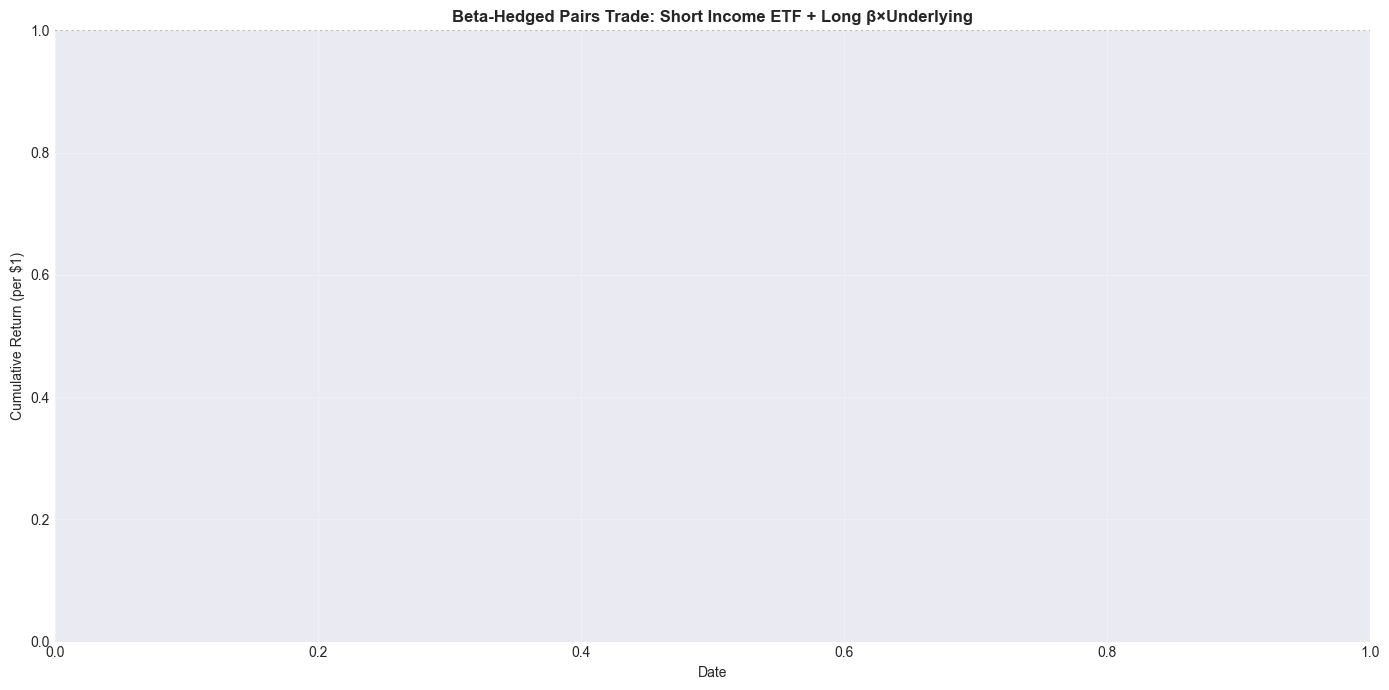

Saved: bucket2_pairs_cumulative.png


In [9]:
pair_results = []

for u in UNIVERSE:
    etf, und = u["etf"], u["underlying"]
    
    if etf not in rets.columns or und not in rets.columns:
        pair_results.append({"ETF": etf, "Underlying": und, "Days": 0,
                            "Beta": u["beta_screener"], "note": "No price data"})
        continue
    
    pair = rets[[etf, und]].dropna()
    if len(pair) < 30:
        pair_results.append({"ETF": etf, "Underlying": und, "Days": len(pair),
                            "Beta": np.nan, "note": "Insufficient data"})
        continue
    
    beta = np.polyfit(pair[und], pair[etf], 1)[0]
    
    # Pair return: short ETF + beta * long underlying
    pair_ret = -pair[etf] + beta * pair[und]
    cum_ret = (1 + pair_ret).cumprod()
    
    # Annualised metrics
    days = len(pair_ret)
    total_ret = cum_ret.iloc[-1] - 1
    ann_ret = (1 + total_ret) ** (252 / max(days, 1)) - 1
    ann_vol = pair_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    
    # Max drawdown
    peak = cum_ret.cummax()
    dd = (cum_ret - peak) / peak
    max_dd = dd.min()
    
    pair_results.append({
        "ETF": etf,
        "Underlying": und,
        "Days": days,
        "Beta": beta,
        "Ann_Return": ann_ret * 100,
        "Ann_Vol": ann_vol * 100,
        "Sharpe": sharpe,
        "Max_DD": max_dd * 100,
        "Total_Ret": total_ret * 100,
    })

pair_df = pd.DataFrame(pair_results).set_index("ETF")
print("=" * 90)
print("BETA-HEDGED PAIRS TRADE — EMPIRICAL PERFORMANCE")
print("=" * 90)
print(pair_df.to_string(float_format="{:.2f}".format))

# Cumulative return chart for all pairs
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.Set2(np.linspace(0, 1, len(UNIVERSE)))

for i, u in enumerate(UNIVERSE):
    etf, und = u["etf"], u["underlying"]
    if etf not in rets.columns or und not in rets.columns:
        continue
    pair = rets[[etf, und]].dropna()
    if len(pair) < 30:
        continue
    beta = np.polyfit(pair[und], pair[etf], 1)[0]
    pair_ret = -pair[etf] + beta * pair[und]
    cum = (1 + pair_ret).cumprod()
    sr = pair_results[i].get("Sharpe", 0) if isinstance(pair_results[i], dict) else 0
    ax.plot(cum.index, cum.values, linewidth=2, color=colors[i],
           label=f"{etf} (β={beta:.2f}, Sharpe={sr:.2f})")

ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (per $1)")
ax.set_title("Beta-Hedged Pairs Trade: Short Income ETF + Long β×Underlying", fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPO / "notebooks" / "bucket2_pairs_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bucket2_pairs_cumulative.png")

## 9. Trade Sizing & Implementation Guide

Practical framework for implementing bucket 2 as a portfolio sleeve.

In [10]:
PORTFOLIO_NAV = 500_000  # example portfolio size
B2_ALLOC = 0.20  # 20% of portfolio to bucket 2
MAX_PER_NAME = 0.05  # 5% max per name

b2_capital = PORTFOLIO_NAV * B2_ALLOC
max_per = PORTFOLIO_NAV * MAX_PER_NAME

print("=" * 80)
print(f"BUCKET 2 TRADE SIZING — ${PORTFOLIO_NAV:,.0f} Portfolio")
print("=" * 80)
print(f"Bucket 2 allocation: {B2_ALLOC:.0%} = ${b2_capital:,.0f}")
print(f"Max per name: {MAX_PER_NAME:.0%} = ${max_per:,.0f} short notional")
print()

sizing_rows = []
for u in UNIVERSE:
    etf = u["etf"]
    r = results_all[etf]
    
    # Use empirical beta if available, else screener beta
    emp_beta = empirical_df.loc[etf, "Beta_to_Und"] if etf in empirical_df.index else u["beta_screener"]
    beta = emp_beta if not np.isnan(emp_beta) else u["beta_screener"]
    
    short_notional = min(max_per, b2_capital / len(UNIVERSE))
    hedge_notional = abs(beta) * short_notional
    
    # Expected annual P&L from this position
    exp_pnl = short_notional * r["short_pnl_mc"] / 100
    
    # Margin: ~90% for short ETF + hedge notional on margin
    margin_short = short_notional * 0.50  # 50% short margin
    margin_long = hedge_notional * 0.50   # 50% Reg-T on long
    total_margin = margin_short + margin_long
    
    sizing_rows.append({
        "ETF": etf,
        "Underlying": u["underlying"],
        "β": beta,
        "Short $": short_notional,
        "Hedge $": hedge_notional,
        "Margin $": total_margin,
        "Short P&L%": r["short_pnl_mc"],
        "Exp P&L $": exp_pnl,
        "Borrow%": u["borrow"] * 100,
    })

sizing_df = pd.DataFrame(sizing_rows).set_index("ETF")
print(sizing_df.to_string(float_format="{:,.1f}".format))
print()
print(f"Total short notional:  ${sizing_df['Short $'].sum():>12,.0f}")
print(f"Total hedge notional:  ${sizing_df['Hedge $'].sum():>12,.0f}")
print(f"Total margin needed:   ${sizing_df['Margin $'].sum():>12,.0f}")
print(f"Expected annual P&L:   ${sizing_df['Exp P&L $'].sum():>12,.0f}")
print(f"Exp return on margin:  {sizing_df['Exp P&L $'].sum() / sizing_df['Margin $'].sum():.1%}")

BUCKET 2 TRADE SIZING — $500,000 Portfolio
Bucket 2 allocation: 20% = $100,000
Max per name: 5% = $25,000 short notional

     Underlying   β  Short $  Hedge $  Margin $  Net Edge%  Exp P&L $  Borrow%
ETF                                                                           
MTYY       MSTR 0.4 12,500.0  4,887.5   8,693.8       67.8    8,470.1      8.4
MAAY       MARA 0.3 12,500.0  3,925.0   8,212.5       66.6    8,327.8      9.8
COYY       COIN 0.5 12,500.0  5,950.0   9,225.0       48.4    6,049.0     26.0
IOYY       IONQ 0.4 12,500.0  4,587.5   8,543.8       71.3    8,912.0      7.7
XBTY       IBIT 0.5 12,500.0  6,762.5   9,631.2       58.9    7,363.9      4.6
TSYY       TSLA 0.5 12,500.0  6,762.5   9,631.2       64.3    8,039.3      5.3
SMCY       SMCI 0.8 12,500.0  9,487.5  10,993.8       71.5    8,932.5      6.3
HOYY       HOOD 0.5 12,500.0  6,387.5   9,443.8       50.9    6,368.7     21.3

Total short notional:  $     100,000
Total hedge notional:  $      48,750
Total margin 

## 10. Mathematical Framework

### The Decay Model

Each income ETF in bucket 2 sells **weekly put spreads** on the corresponding **2× daily leveraged ETF**.
The fund distributes the premium and retains the residual NAV. The key dynamics:

#### Step 1: MSTU-like daily compounding

If the underlying stock has daily return $r_t$, the 2× leveraged ETF return is $2r_t$.
Over a week of $n=5$ days:

$$R_{\text{week}} = \prod_{t=1}^{5}(1 + 2r_t)$$

Under GBM with annualised vol $\sigma$ and drift $\mu$, this weekly return ratio is approximately
lognormal:

$$\ln R \sim \mathcal{N}\bigl((2\mu - 2\sigma^2)\tau,\; (2\sigma)^2\tau\bigr)$$

where $\tau = 5/252$ is one week in years. The **$-2\sigma^2$** term is the leveraged volatility drag.

#### Step 2: Weekly NAV update

$$\text{NAV}_{w+1} = \text{NAV}_w \times (1 - L_w - f)$$

where $L_w$ is the put-spread intrinsic loss (as a fraction of NAV) and $f = 0.99\%/52$
is the weekly expense ratio.

#### Step 3: Expected weekly loss

The expected spread loss under physical measure is:

$$\mathcal{L} = K_h\Phi(\alpha_h) - F\Phi(\beta_h) - K_l\Phi(\alpha_l) + F\Phi(\beta_l)$$

where:
- $K_h = 0.95$ (short strike), $K_l = 0.88$ (long strike)
- $F = e^{2\mu\tau}$ (forward price of 2× return)
- $\alpha_x = \frac{\ln K_x - (2\mu - 2\sigma^2)\tau}{2\sigma\sqrt{\tau}}$
- $\beta_x = \alpha_x - 2\sigma\sqrt{\tau}$

#### Step 4: Annual decay

$$\boxed{\text{decay}(\sigma) = 1 - (1 - \mathcal{L} - f)^{52}}$$

#### Step 5: Short seller's P&L (corrected for distributions)

The short seller's P&L has **three components**:
1. **NAV Decay** (profit): the price drops → short profits
2. **Distributions paid** (cost): short must pay actual dividends to share lender
3. **Borrow cost** (cost): fee to borrow shares

$$\text{Net Short P\&L} = \underbrace{(1 - q^{52})}_{\text{NAV decay}} - \underbrace{d \cdot \frac{1-q^{52}}{1-q}}_{\text{distributions}} - \text{borrow}$$

where $d$ is the actual weekly distribution rate (from dividendhistory.org) and $q = 1 - \mathcal{L} - f$.

**Critical insight**: Actual distributions ($d \approx 1.6\%-1.9\%$/week) are *less* than the theoretical BS premium
($\approx 2.5\%-3.5\%$/week), so $\mathcal{L} > d$ and the short seller profits from the gap.

### Key Insight: Volatility Drives Everything

The decay depends **primarily on the underlying's volatility** ($\sigma$), not its drift ($\mu$).
This is because the 2× leveraged ETF's weekly vol (~$2\sigma\sqrt{\tau}$) dwarfs any weekly drift.
The strategy is therefore robust to whether the underlying goes up or down.

### Why This Differs from Standard LETF Decay

The standard LETF volatility drag formula $\frac{1}{2}\beta(\beta-1)\sigma^2$ gives ~9% for
MTYY-like parameters. But that formula describes the **tracking error** of a buy-and-hold leveraged
position. Income ETFs like MTYY have **five additional decay channels**:

1. **Distribution drain**: 100% of premium is distributed, leaving NAV exposed to full losses
2. **Put-spread intrinsic loss**: ~47% of weeks the spread loses money
3. **Geometric compounding**: losses reduce NAV, which reduces future premium base
4. **VRP leakage**: IV > RV means premiums collected < theoretical fair value
5. **Fat tails**: Student-t(5) innovations add ~2pp to decay vs lognormal

## 11. Implementation Playbook

### Constructing the Beta-Hedged Trade

For each name:

| Step | Action | Detail |
|------|--------|--------|
| 1 | **Short** the income ETF | E.g., short \$25k of MTYY |
| 2 | **Long** β × underlying | If β=0.39, long \$9.75k of MSTR |
| 3 | **Rebalance** weekly/monthly | Re-estimate β, adjust hedge ratio |
| 4 | **Monitor** borrow cost | Exit if borrow > decay edge |

### Risk Management

- **Position limits**: 5% of portfolio per name, 20% aggregate bucket 2
- **Borrow monitoring**: Flag if borrow cost exceeds 50% of expected decay
- **Volatility regime**: Higher vol = more decay = bigger edge. Monitor for vol compression
- **Liquidity**: Check shares available for borrow; reject names with < 1,000 shares

### Entry Criteria

1. `decay_score > 0.10` from daily screener
2. `net_decay_annual > 0` (decay exceeds borrow)
3. `shares_available > 1,000`
4. Underlying vol > 40% (ensures meaningful decay)

### When to Exit

- Underlying vol drops below 30% (decay insufficient)
- Borrow cost spikes above net short P&L
- Distribution rate increases significantly
- Fund restructures or changes strategy
- Beta becomes unstable (rolling β swings > 50%)

In [11]:
# ── Final ranked summary ──────────────────────────────────────────────────────
final_rows = []
for u in UNIVERSE:
    etf = u["etf"]
    r = results_all[etf]
    pr = next((p for p in pair_results if p["ETF"] == etf), {})
    
    final_rows.append({
        "ETF": etf,
        "Underlying": u["underlying"],
        "σ_und": f"{u['vol_und']:.0%}",
        "MC Decay": f"{r['decay_mc_mean']:.1f}%",
        "Theory": f"{r['decay_theory']:.1f}%",
        "Borrow": f"{u['borrow']:.1%}",
        "Short P&L": f"{r['short_pnl_mc']:+.1f}%",
        "β": f"{u['beta_screener']:.2f}",
        "Emp Sharpe": f"{pr.get('Sharpe', float('nan')):.2f}",
        "ITM%": f"{r['itm_mc']:.0f}%",
        "Wipeout": f"{r['wipeout_pct']:.1f}%",
    })

final_df = pd.DataFrame(final_rows).set_index("ETF")

print("\n" + "=" * 110)
print("BUCKET 2 INCOME ETF DECAY ANALYSIS — FINAL RANKINGS")
print("=" * 110)
print(final_df.to_string())
print("\nRanked by net short P&L (NAV decay − distributions − borrow). Higher = better short candidate.")
print("\nKey: σ_und=underlying annual vol, MC Decay=10k-sim mean NAV decay,")
print("     Short P&L=after distributions+borrow, β=beta to underlying, ITM%=weeks spread in-the-money")


BUCKET 2 INCOME ETF DECAY ANALYSIS — FINAL RANKINGS
     Underlying σ_und MC Decay Theory Borrow Net Edge     β Emp Sharpe ITM% Wipeout
ETF                                                                                
MTYY       MSTR   88%    76.2%  78.0%   8.4%    67.8%  0.39        nan  45%    0.0%
MAAY       MARA   90%    76.4%  78.3%   9.8%    66.6%  0.31        nan  45%    0.0%
COYY       COIN   79%    74.4%  76.3%  26.0%    48.4%  0.48        nan  43%    0.0%
IOYY       IONQ  108%    79.0%  80.8%   7.7%    71.3%  0.37        nan  47%    0.0%
XBTY       IBIT   50%    63.5%  65.7%   4.6%    58.9%  0.54        nan  37%    0.0%
TSYY       TSLA   63%    69.6%  71.7%   5.3%    64.3%  0.54        nan  40%    0.0%
SMCY       SMCI   98%    77.8%  79.6%   6.3%    71.5%  0.76        nan  46%    0.0%
HOYY       HOOD   71%    72.2%  74.2%  21.3%    50.9%  0.51        nan  42%    0.0%

Ranked by net edge (MC decay − borrow cost). Higher = better short candidate.

Key: σ_und=underlying annua